<a id="07"></a>

## 07 — Leave-One-Load-Out (LOLO) Visualization
### Mục 0.3 (phần 2) — Trực quan hóa cấu trúc kiểm định LOLO

**Mục đích**: trực quan hóa cấu trúc 4-fold LOLO (định nghĩa chính thức ở
mục 2.1 của đề cương) và kiểm tra độ cân bằng số file giữa các mức tải
trước khi dùng làm cấu trúc kiểm định chính thức cho toàn đề tài.

Hàm `generate_lolo_folds()` dùng ở đây được **import nguyên vẹn** từ
`common/splitting.py`

**Giới hạn cần nhớ (mục 0.4 của đề cương)**: LOLO trên CWRU đo tổng quát
hóa qua **điều kiện tải**, không phải qua **vòng bi vật lý độc lập** — vì
CWRU dùng chung 1 vòng bi qua nhiều mức tải liên tiếp.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [2]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False  # manifest đã được build ở notebook 01

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning,resolved_sample_rate_hz
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,NaN,NaN,False,12000.0
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,NaN,NaN,False,12000.0
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,NaN,NaN,False,12000.0
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,NaN,NaN,False,12000.0
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,NaN,NaN,False,12000.0


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [4]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Cấu trúc 4 fold

In [5]:
folds = splitting.generate_lolo_folds(loads=(0, 1, 2, 3))
for fold in folds:
    print(f"Test = tải {{{fold['test_load']}}}  |  Train/Val = tải {fold['trainval_loads']}")

Test = tải {0}  |  Train/Val = tải [1, 2, 3]
Test = tải {1}  |  Train/Val = tải [0, 2, 3]
Test = tải {2}  |  Train/Val = tải [0, 1, 3]
Test = tải {3}  |  Train/Val = tải [0, 1, 2]


## Sơ đồ trực quan cấu trúc LOLO

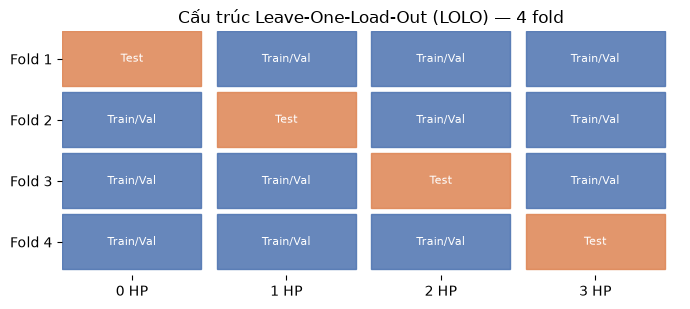

In [6]:
loads = [0, 1, 2, 3]
fig, ax = plt.subplots(figsize=(7, 3.2))

color_trainval = "#4C72B0"
color_test = "#DD8452"

for fold_idx, fold in enumerate(folds):
    for load in loads:
        is_test = (load == fold["test_load"])
        color = color_test if is_test else color_trainval
        
        ax.add_patch(Rectangle((load, fold_idx), 0.9, 0.9, color=color, alpha=0.85))
        label = "Test" if is_test else "Train/Val"
        ax.text(load + 0.45, fold_idx + 0.45, label, ha="center", va="center",
                fontsize=8, color="white")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_xticks([l + 0.45 for l in loads])
ax.set_xticklabels([f"{l} HP" for l in loads])
ax.set_yticks([i + 0.45 for i in range(4)])
ax.set_yticklabels([f"Fold {i+1}" for i in range(4)])
ax.set_title("Cấu trúc Leave-One-Load-Out (LOLO) — 4 fold")
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_lolo_structure.png", dpi=150)
plt.show()

## Kiểm tra cân bằng số file giữa các mức tải (ảnh hưởng trực tiếp đến từng fold)

load_hp
0    10
1    10
2    10
3    10
Name: file_path, dtype: int64


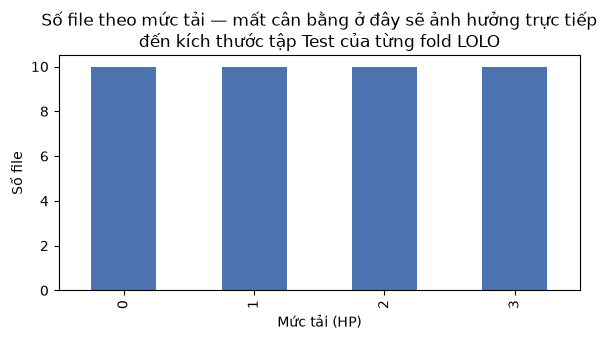


Tỉ lệ lệch lớn nhất giữa các tải: 1.00x
=> Tương đối cân bằng giữa các tải.


In [7]:
counts_by_load = manifest.groupby("load_hp")["file_path"].count()
print(counts_by_load)

fig, ax = plt.subplots(figsize=(6, 3.5))
counts_by_load.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Mức tải (HP)")
ax.set_ylabel("Số file")
ax.set_title("Số file theo mức tải — mất cân bằng ở đây sẽ ảnh hưởng trực tiếp\nđến kích thước tập Test của từng fold LOLO")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_file_count_by_load.png", dpi=150)
plt.show()

max_ratio = counts_by_load.max() / counts_by_load.min()
print(f"\nTỉ lệ lệch lớn nhất giữa các tải: {max_ratio:.2f}x")
if max_ratio > 1.5:
    print("=> Lệch đáng kể — cân nhắc ghi chú ảnh hưởng này khi phân tích "
          "kết quả từng fold ở Giai đoạn 2 (mục 2.1: fold nào thấp hơn hẳn "
          "cần được phân tích nguyên nhân).")
else:
    print("=> Tương đối cân bằng giữa các tải.")

## Ghi chú cho báo cáo

- Sơ đồ `07_lolo_structure.png` dùng trực tiếp minh họa mục 2.1 của báo cáo.
- Nếu số file lệch đáng kể giữa các tải, cần nêu rõ trong phần Thảo luận
  khi một fold LOLO cho kết quả thấp hơn hẳn các fold còn lại.
- Nhắc lại giới hạn LOLO trên CWRU (đã nêu ở mục 0.4/Phạm vi & giới hạn) —
  nên đặt ngay cạnh sơ đồ này trong báo cáo để người đọc không hiểu nhầm
  đây là kiểm định qua vòng bi độc lập.